## AgERA5 Weather Extraction per NUTS3 Site 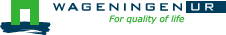
------------------------------
For every selected NUTS3 centroid (from `sites.csv`), this notebook queries the WUR AgERA5 API directly (same framework as the Veenkampen weather notebook), converts the variables to PCSE units, and writes one `CSVWeatherDataProvider` file per site. Those CSV files act as an **offline cache**: the API is only hit once (run this on the WUR network), and afterwards the providers load from disk without any connection. Each loaded provider is a `WeatherDataProvider` ready for WOFOST.

> The AgERA5 API (`agera5.containers.wurnet.nl`) is only reachable on the WUR network / VPN, so do the fetch step on campus.

In [20]:
import pandas as pd
import requests
from pathlib import Path
from pcse.input import CSVWeatherDataProvider

HOST = "https://agera5.containers.wurnet.nl/"   # WUR network / VPN only
START, END = "20181001", "20231231"            # set to your simulation window (YYYYMMDD)
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "sites_geopandas").exists():
    ROOT = ROOT.parent

SITES       = ROOT / "sites_geopandas" / "nuts3_centroid.csv"
WEATHER_DIR = ROOT / "weather" / "agera5_csv"

In [21]:
# write a DataFrame to a CSVWeatherDataProvider-format file
def write_pcse_csv(df, path, latitude, longitude, elevation=0.0, country='NA', station='site'):
    L = ['## Site Characteristics',
         f"Country = '{country}'", f"Station = '{station}'",
         "Description = 'AgERA5 daily weather at NUTS3 centroid'",
         "Source = 'AgERA5 via WUR get_agera5 API'", "Contact = 'NA'",
         f'Longitude = {longitude}; Latitude = {latitude}; Elevation = {elevation}; '
         f'AngstromA = 0.18; AngstromB = 0.55; HasSunshine = False',
         '## Daily weather observations (missing values are NaN)',
         'DAY,IRRAD,TMIN,TMAX,VAP,WIND,RAIN,SNOWDEPTH']
    for day, r in df.iterrows():
        L.append(f"{day.strftime('%Y%m%d')},{r.IRRAD},{r.TMIN},{r.TMAX},{r.VAP},{r.WIND},{r.RAIN},{r.SNOWDEPTH}")
    Path(path).write_text('\n'.join(L) + '\n')

In [22]:
# AgERA5 variable name -> PCSE variable (same mapping as the Veenkampen notebook)
agera5_map = {
    "IRRAD": "radiation",
    "TMIN":  "temperature_min",
    "TMAX":  "temperature_max",
    "VAP":   "vapourpressure",
    "WIND":  "windspeed",
    "RAIN":  "precipitation",
}

def fetch_agera5(lat, lon, start, end):
    """Query the WUR AgERA5 API and convert to PCSE CSV-file units (kJ/m2, kPa, mm)."""
    url = f"{HOST}api/v1/get_agera5?latitude={lat}&longitude={lon}&startdate={start}&enddate={end}"
    resp = requests.get(url, timeout=120)
    resp.raise_for_status()
    a = pd.DataFrame(resp.json()["weather_variables"])
    a.index = pd.to_datetime(a["day"])

    out = pd.DataFrame(index=a.index)
    out["IRRAD"] = a[agera5_map["IRRAD"]].astype(float) / 1000.0   # J/m2/day -> kJ/m2/day
    out["TMIN"]  = a[agera5_map["TMIN"]].astype(float)             # C
    out["TMAX"]  = a[agera5_map["TMAX"]].astype(float)             # C
    out["VAP"]   = a[agera5_map["VAP"]].astype(float) * 0.1        # hPa -> kPa
    out["WIND"]  = a[agera5_map["WIND"]].astype(float)             # m/s
    out["RAIN"]  = a[agera5_map["RAIN"]].astype(float)             # mm
    out["SNOWDEPTH"] = float("nan")
    return out

In [23]:
# STEP 1 - fetch + write one CSV per site (NEEDS WUR NETWORK; run on campus).
# Sites whose CSV already exists are skipped, so re-running is cheap.
sites = pd.read_csv(SITES)            # columns: nuts3, constraints, lon, lat
WEATHER_DIR.mkdir(exist_ok=True)

for s in sites.itertuples():
    csv_path = WEATHER_DIR / f"{s.nuts3}.csv"
    if csv_path.exists():
        continue
    try:
        df = fetch_agera5(s.lat, s.lon, START, END)
        write_pcse_csv(df, csv_path, latitude=s.lat, longitude=s.lon,
                       country=s.nuts3[:2], station=s.nuts3)
        print(f"{s.nuts3:6s} fetched ({len(df)} days)")
    except Exception as e:
        print(f"{s.nuts3:6s} FAILED -- {e}")

AT111  fetched (1918 days)
AT121  fetched (1918 days)
AT124  fetched (1918 days)
AT211  fetched (1918 days)
AT212  fetched (1918 days)
AT213  fetched (1918 days)
AT222  fetched (1918 days)
AT223  fetched (1918 days)
AT226  fetched (1918 days)
AT314  fetched (1918 days)
AT315  fetched (1918 days)
AT321  fetched (1918 days)
AT322  fetched (1918 days)
AT323  fetched (1918 days)
AT331  fetched (1918 days)
AT332  fetched (1918 days)
AT333  fetched (1918 days)
AT334  fetched (1918 days)
AT335  fetched (1918 days)
AT341  fetched (1918 days)
AT342  fetched (1918 days)
BG411  fetched (1918 days)
BG413  fetched (1918 days)
BG423  fetched (1918 days)
BG424  fetched (1918 days)
DE139  fetched (1918 days)
DE147  fetched (1918 days)
DE148  fetched (1918 days)
DE213  fetched (1918 days)
DE215  fetched (1918 days)
DE216  fetched (1918 days)
DE218  fetched (1918 days)
DE21D  fetched (1918 days)
DE21F  fetched (1918 days)
DE21K  fetched (1918 days)
DE21L  fetched (1918 days)
DE21M  fetched (1918 days)
D

In [24]:
# STEP 2 - load each CSV into a PCSE provider (NO network; works anywhere).
wdps = {}
for s in sites.itertuples():
    csv_path = WEATHER_DIR / f"{s.nuts3}.csv"
    if csv_path.exists():
        wdps[s.nuts3] = CSVWeatherDataProvider(str(csv_path))

print(f"{len(wdps)}/{len(sites)} weather providers ready.")

334/334 weather providers ready.


In [25]:
# sanity check on one site
import datetime as dt
w = wdps[sites.iloc[0]["nuts3"]]
print(w(dt.date(2020, 7, 1)))   # IRRAD J/m2/day, VAP hPa, RAIN cm/day, temps C  (+ E0/ES0/ET0)

Weather data for 2020-07-01 (DAY)
IRRAD:  22669750.00  J/m2/day
 TMIN:        16.03   Celsius
 TMAX:        28.89   Celsius
  VAP:        18.44       hPa
 RAIN:         0.45    cm/day
   E0:         0.57    cm/day
  ES0:         0.51    cm/day
  ET0:         0.49    cm/day
 WIND:         2.03     m/sec
Latitude  (LAT):    47.51 degr.
Longitude (LON):    16.48 degr.
Elevation (ELEV):    0.0 m.

